In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import io
import base64
from jupyter_bbox_widget import BBoxWidget
import matplotlib.patches as patches

# Use the function from previous notebook
def show_mask(mask, ax, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), [0.6]])
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])

    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)

    ax.imshow(mask_image)


In [3]:
image = cv2.imread('data/pedestrian_day.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [5]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from PIL import Image

# Load a pre-trained Faster R-CNN model
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load an image tensor
image_tensor = F.to_tensor(image)

# Perform inference
with torch.no_grad():
    prediction = model([image_tensor])

person_label = 1
threshold = 0.5

labels = prediction[0]["labels"]
all_boxes = prediction[0]["boxes"]
all_scores = prediction[0]["scores"]

person_indices = (labels == person_label) & (all_scores > threshold)

boxes = all_boxes[person_indices]
scores = all_scores[person_indices]

# Print the detections for people
print("Boxes:", boxes)
print("Scores:", scores)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Boxes: tensor([[212.9838, 107.0880, 376.8011, 683.6193]])
Scores: tensor([0.9997])


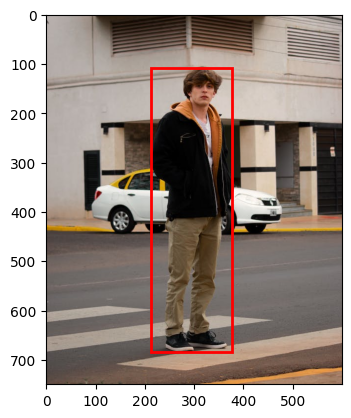

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Filter the detections for people
boxes = boxes.numpy()
scores = scores.numpy()

# Create a matplotlib figure
fig, ax = plt.subplots(1)

# Display the image
ax.imshow(image)

# Draw bounding boxes on the image
for box in boxes:
    x1, y1, x2, y2 = box
    
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth = 2,
        edgecolor = 'r',
        facecolor = 'none'
    )
    ax.add_patch(rect)

# Show the figure
plt.show()

In [7]:
from segment_anything import sam_model_registry, SamPredictor

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "data/sam_vit_h_4b8939.pth"
model_type = "vit_h"

device="cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)


In [8]:
print(boxes)

[[212.9838  107.08802 376.80112 683.61926]]


In [9]:
import cv2
import numpy as np

predictor.set_image(image)


masks, scores, logits = predictor.predict(
    box=boxes[0],
    multimask_output=True
)

[0.89415115 1.0023754  0.99970543]


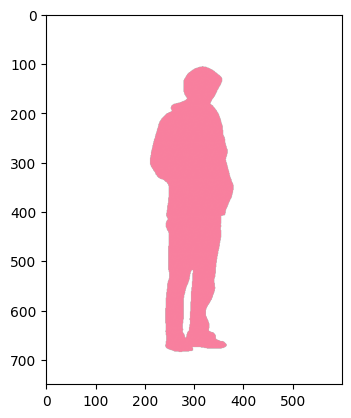

In [13]:
print(scores)

#take the index of the highest score


max_score = np.argmax(scores) 

# Select the mask with the highest score
mask_with_max_score = masks[max_score]

show_mask(mask_with_max_score, plt.gca())


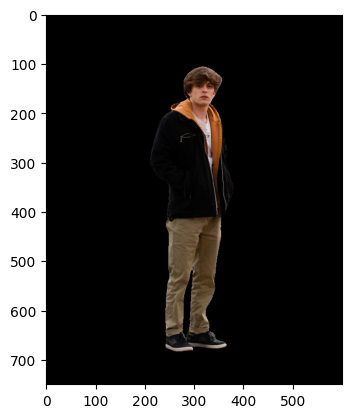

In [14]:


mask_with_max_score = mask_with_max_score.astype(bool)


masked_image = image.copy()
masked_image[~mask_with_max_score] = 0

# Display the masked image
plt.imshow(masked_image)
plt.show()

In [15]:
background_image = cv2.imread('data/road.jpg')
background_image = cv2.cvtColor(background_image, cv2.COLOR_BGR2RGB)


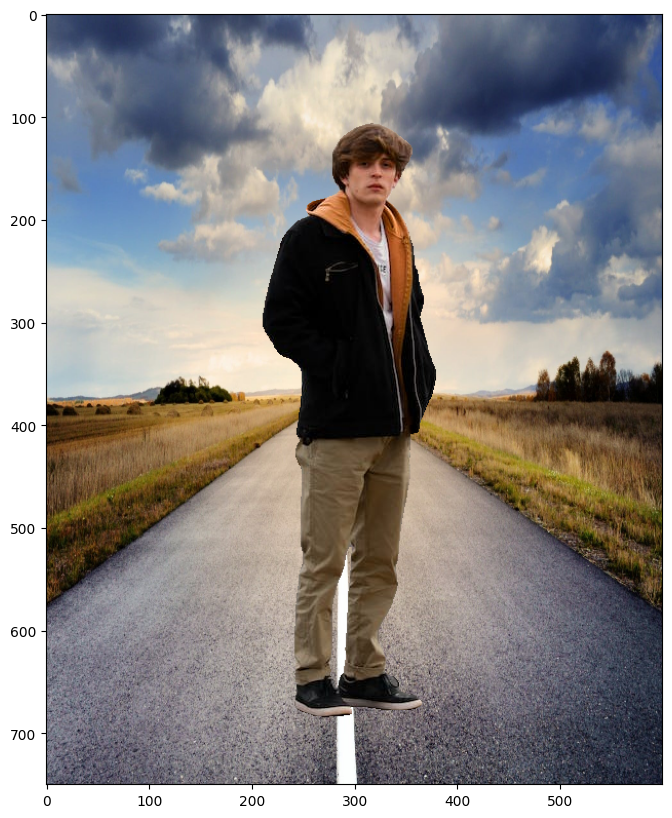

In [17]:
# Make sure the background image is the same size as the original image
background_image = cv2.resize(background_image, (image.shape[1], image.shape[0]))


composite_image = np.where(
    mask_with_max_score[..., None],
    image,
    background_image
)

plt.figure(figsize=(10,10))

# Display the composite image
plt.imshow(composite_image)
plt.show()